In [ ]:
from torch import (
    Tensor,
    tensor,
    stack,
    arange,
    zeros as zeros_tensor,
    save as torch_save,
    float64 as torch_float64,
    float32 as torch_float32,
)

from scanner_modeling.geometry_2d import (
    fov_tensor_dict,
    load_scanner_geometry_from_layout,
    load_scanner_layouts,
	fov_corners_vertices_2d,
	points_to_refs_angle_2d_batch,
)
from scanner_modeling.raytracer_2d import (
    ppdf_2d_local,
    sfov_properties,
    subdivision_grid_rectangle,
)
from typing import Dict, List, Tuple
from matplotlib import pyplot as plt
from matplotlib.collections import PolyCollection,LineCollection

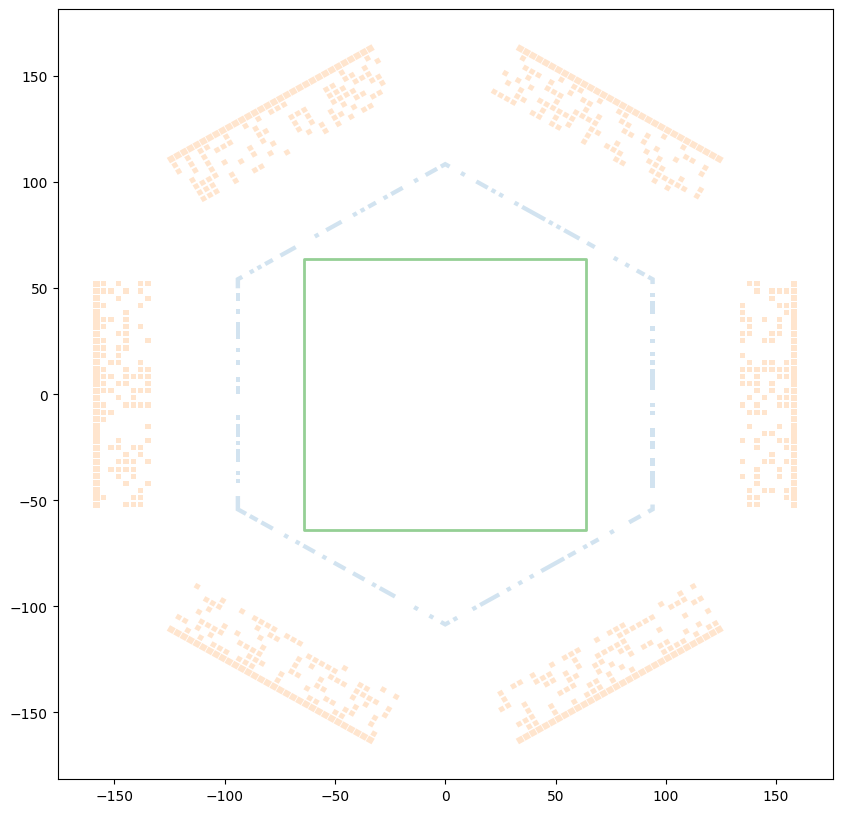

In [2]:
scanner_layouts, layouts_md5 = load_scanner_layouts(
    "scanner_layouts", "scanner_layouts_77faff53af5863ca146878c7c496c75e.tensor"
)
(
    plate_objects_vertices,
    crystal_objects_vertices,
    plate_objects_edges,
    crystal_objects_edges,
) = load_scanner_geometry_from_layout(0, scanner_layouts)
fov_dict = fov_tensor_dict((64, 64), (128, 128), (0.0, 0.0), (1, 1))
fov_corners = fov_corners_vertices_2d(fov_dict)
fig, ax = plt.subplots(figsize=(10, 10))
plate_objects_polycoll = PolyCollection(
    list(plate_objects_vertices), fc="C0", ec="None", alpha=0.2
)
crystal_objects_polycoll = PolyCollection(
    list(crystal_objects_vertices), fc="C1", ec="None", alpha=0.2
)
fov_frame_polycoll = PolyCollection(
    list(fov_corners.unsqueeze(0)), fc="None", ec="C2", alpha=0.5, lw=2
)
ax.add_collection(fov_frame_polycoll)
ax.add_collection(crystal_objects_polycoll)
ax.add_collection(plate_objects_polycoll)
ax.autoscale()

In [ ]:
from scanner_modeling._convex_hull._convex_hull_functions import (
    convex_hull_2d,
    sort_points_for_hull_2d,
)
from scanner_modeling._raytracer_2d._local_functions import (
    subdivision_vertices_rectangle,
    rays_edges_t_subdivisions,
    rays_intersection_lengths,
    line_segments_t,
    rays_2d_batch,
)
from scanner_modeling._geometry_2d._geometry_2d_polygon import (
    reduced_scanner_objects_ids_local,
    polygon_edges_from_vertices_2d_batch,
)

from torch import cat, pi


def ppdf_2d_local_dev(
    fov_idx: int,
    crystal_idx: int,
    sfov_pixels_batch: Tensor,
    sfov_corners_batch: Tensor,
    plate_objects_vertices: Tensor,
    crystal_objects_vertices: Tensor,
    plate_objects_edges: Tensor,
    crystal_objects_edges: Tensor,
    subdivision_grid: Tensor,
    mu_dict: Dict,
):
    """
    Calculate the ppdf of a section of the the entire FOV. 2D version.

    Parameters
    ----------
    fov_idx : int
        The index of the local field of view.

    crystal_idx : int
        The index of the crystal object of which the PPDF is calculated.

    sfov_pixels_batch : Tensor
        The pixel centers of the subfield of views.
        shape: (n_subdivisions, n_pixels, 2)

    sfov_corners_batch : Tensor
        The corners of the subfield of views.
        shape: (n_subdivisions, 4, 2)

    plate_objects_vertices : Tensor
        The vertices of the plate objects.
        shape: (n_plate_objects, 4, 2)

    crystal_objects_vertices : Tensor
        The vertices of the crystal objects.
        shape: (n_crystal_objects, 4, 2)

    plate_objects_edges : Tensor
        The edges of the plate objects.
        shape: (n_plate_objects, 4, 2, 2)

    crystal_objects_edges : Tensor
        The edges of the crystal objects.
        shape: (n_crystal_objects, 4, 2, 2)

    subdivision_grid : Tensor
        The grid used for subdivision.
        shape: (n_subdivisions, 4, 2)

    Returns
        -------
        Tensor
            The computed ppdf values.
        shape: (n_fov, n_plate_objects, n_crystal_objects, n_subdivisions)
    """

    sub_crystals_vertices = subdivision_vertices_rectangle(
        crystal_objects_vertices[crystal_idx], subdivision_grid
    )

    local_hull = convex_hull_2d(
        sort_points_for_hull_2d(
            cat(
                (
                    sfov_corners_batch[fov_idx],
                    crystal_objects_vertices[crystal_idx],
                ),
                dim=0,
            )
        )
    )
    reduced_plate_objects_ids, reduced_crystal_objects_ids = (
        reduced_scanner_objects_ids_local(
            crystal_idx,
            local_hull,
            plate_objects_vertices,
            crystal_objects_vertices,
            plate_objects_edges,
            crystal_objects_edges,
        )
    )

    reduced_plate_edges = plate_objects_edges[reduced_plate_objects_ids]
    reduced_crystal_edges = crystal_objects_edges[reduced_crystal_objects_ids]
    print(
        f"reduced_plate_objects_ids: {reduced_plate_objects_ids.shape}, "
        f"reduced_crystal_objects_ids: {reduced_crystal_objects_ids.shape}"
    )
    print(
        f"reduced_plate_edges: {reduced_plate_edges.shape}, "
        f"reduced_crystal_edges: {reduced_crystal_edges.shape}"
    )
    sub_crystals_edges = polygon_edges_from_vertices_2d_batch(
        sub_crystals_vertices
    )

    pa_batch = sfov_pixels_batch[fov_idx]
    pb_batch = sub_crystals_vertices.mean(dim=1)

    rays = rays_2d_batch(pa_batch, pb_batch)
    rays_plates_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_plate_edges.view(-1, 2, 2)
    )
    rays_crystal_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_crystal_edges.view(-1, 2, 2)
    )
    rays_sub_crystal_t = rays_edges_t_subdivisions(rays, sub_crystals_edges)

    print(
        f"rays_plates_transmission_t: {rays_plates_transmission_t.shape}, "
        f"rays_crystal_transmission_t: {rays_crystal_transmission_t.shape}, "
        f"rays_sub_crystal_t: {rays_sub_crystal_t.shape}"
    )

    intersection_length_plates = rays_intersection_lengths(
        rays, rays_plates_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)
    intersection_length_crystals = rays_intersection_lengths(
        rays, rays_crystal_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)

    intersection_length_subdivisions = rays_intersection_lengths(
        rays, rays_sub_crystal_t
    ).view(rays.shape[0], rays.shape[1])

    sub_crystals_vertices_rads = points_to_refs_angle_2d_batch(
        sub_crystals_vertices.view(-1, 2), pa_batch
    ).view(
        pa_batch.shape[0],
        sub_crystals_vertices.shape[0],
        sub_crystals_vertices.shape[1],
    )
    
    subdivision_rads_span = (
        sub_crystals_vertices_rads.max(dim=2).values
        - sub_crystals_vertices_rads.min(dim=2).values
    )

    sum_plate_exponent = (
        intersection_length_plates * float(mu_dict["plate"])
    ).sum(dim=2)
    sum_crystal_exponent = (
        intersection_length_crystals * float(mu_dict["crystal"])
    ).sum(dim=2)
    subdivision_exponent = intersection_length_subdivisions * float(
        mu_dict["crystal"]
    )
    angular_term = subdivision_rads_span / (2.0 * pi)
    return (
        (
            (-sum_plate_exponent - sum_crystal_exponent).exp()
            * (subdivision_exponent.exp() - 1)
            * angular_term
        ).sum(dim=1),
        local_hull,
        reduced_plate_objects_ids,
        reduced_crystal_objects_ids,
        intersection_length_plates,
        intersection_length_crystals,
        intersection_length_subdivisions,
        rays_plates_transmission_t,
        rays_crystal_transmission_t,
        rays_sub_crystal_t,
        pa_batch,
        rays,
    )


from torch import argwhere, where


def rays_intersection_lengths_dev(
    rays: Tensor,
    rays_t: Tensor,
):
    """
    Calculate the intersection lengths of the rays given the t values.
    """
    # rays = rays.view(-1, 2, 2).to(torch_float32)
    rays = rays.view(-1, 2, 2)
    # rays_t_reshaped = rays_t.reshape(rays.shape[0], -1, 4).to(torch_float32)
    rays_t_reshaped = rays_t.reshape(rays.shape[0], -1, 4)
    rays_t_sorted = rays_t_reshaped.sort(dim=2).values
    rays_t_diff = rays_t_sorted[:, :, -1] - rays_t_sorted[:, :, -2]

    # rays_t_diff = where(rays_t_diff > 1 - eps, 2 - rays_t_diff, rays_t_diff)
    length = rays_t_diff * (rays[:, 1] - rays[:, 0]).norm(
        dim=1, dtype=torch_float64
    ).view(-1, 1)
    indices = argwhere(length > 0)
    points = rays[indices[:, 0], 0].view(-1, 1, 2).expand(-1, 2, -1) + (
        rays[indices[:, 0], 1] - rays[indices[:, 0], 0]
    ).view(-1, 1, 2).expand(-1, 2, -1) * rays_t_sorted[
        indices[:, 0], indices[:, 1], -2:
    ].view(
        -1, 2, 1
    ).expand(
        -1, -1, 2
    )

    return length, points

In [4]:
fov_dict = fov_tensor_dict((32,32), (128, 128), (0, 0), (1, 1))
crystal_n_subs = (3, 3)
sfov_pxs_ids, sfov_pxs_coords, sfov_corners_batch = sfov_properties(fov_dict)
subdivision_grid = subdivision_grid_rectangle(crystal_n_subs)
(
    ppdf,
    local_hull,
    reduced_plate_objects_ids,
    reduced_crystal_objects_ids,
    intersection_length_plates,
    intersection_length_crystals,
    intersection_length_subdivisions,
    rays_plates_transmission_t,
    rays_crystal_transmission_t,
    rays_sub_crystal_t,
    pa_batch,
    rays,
) = ppdf_2d_local_dev(
    0,
    2,
    sfov_pxs_coords,
    sfov_corners_batch,
    plate_objects_vertices,
    crystal_objects_vertices,
    plate_objects_edges,
    crystal_objects_edges,
    subdivision_grid,
    {"plate": 3.5, "crystal": 0.475},
)

intersection_length_plates, intersection_points_plates = rays_intersection_lengths_dev(
    rays, rays_plates_transmission_t
)
intersection_length_crystals, intersection_points_crystals = rays_intersection_lengths_dev(
    rays, rays_crystal_transmission_t
)
print(
    f"intersection_points_plates: {intersection_points_plates.shape}\n"
    f"intersection_points_crystals: {intersection_points_crystals.shape}"
)

reduced_plate_objects_ids: torch.Size([10]), reduced_crystal_objects_ids: torch.Size([1])
reduced_plate_edges: torch.Size([10, 4, 2, 2]), reduced_crystal_edges: torch.Size([1, 4, 2, 2])
rays_plates_transmission_t: torch.Size([9216, 40]), rays_crystal_transmission_t: torch.Size([9216, 4]), rays_sub_crystal_t: torch.Size([1024, 9, 4])
intersection_points_plates: torch.Size([5249, 2, 2])
intersection_points_crystals: torch.Size([9216, 2, 2])


(tensor(-64.), tensor(64.), tensor(-64.), tensor(64.))


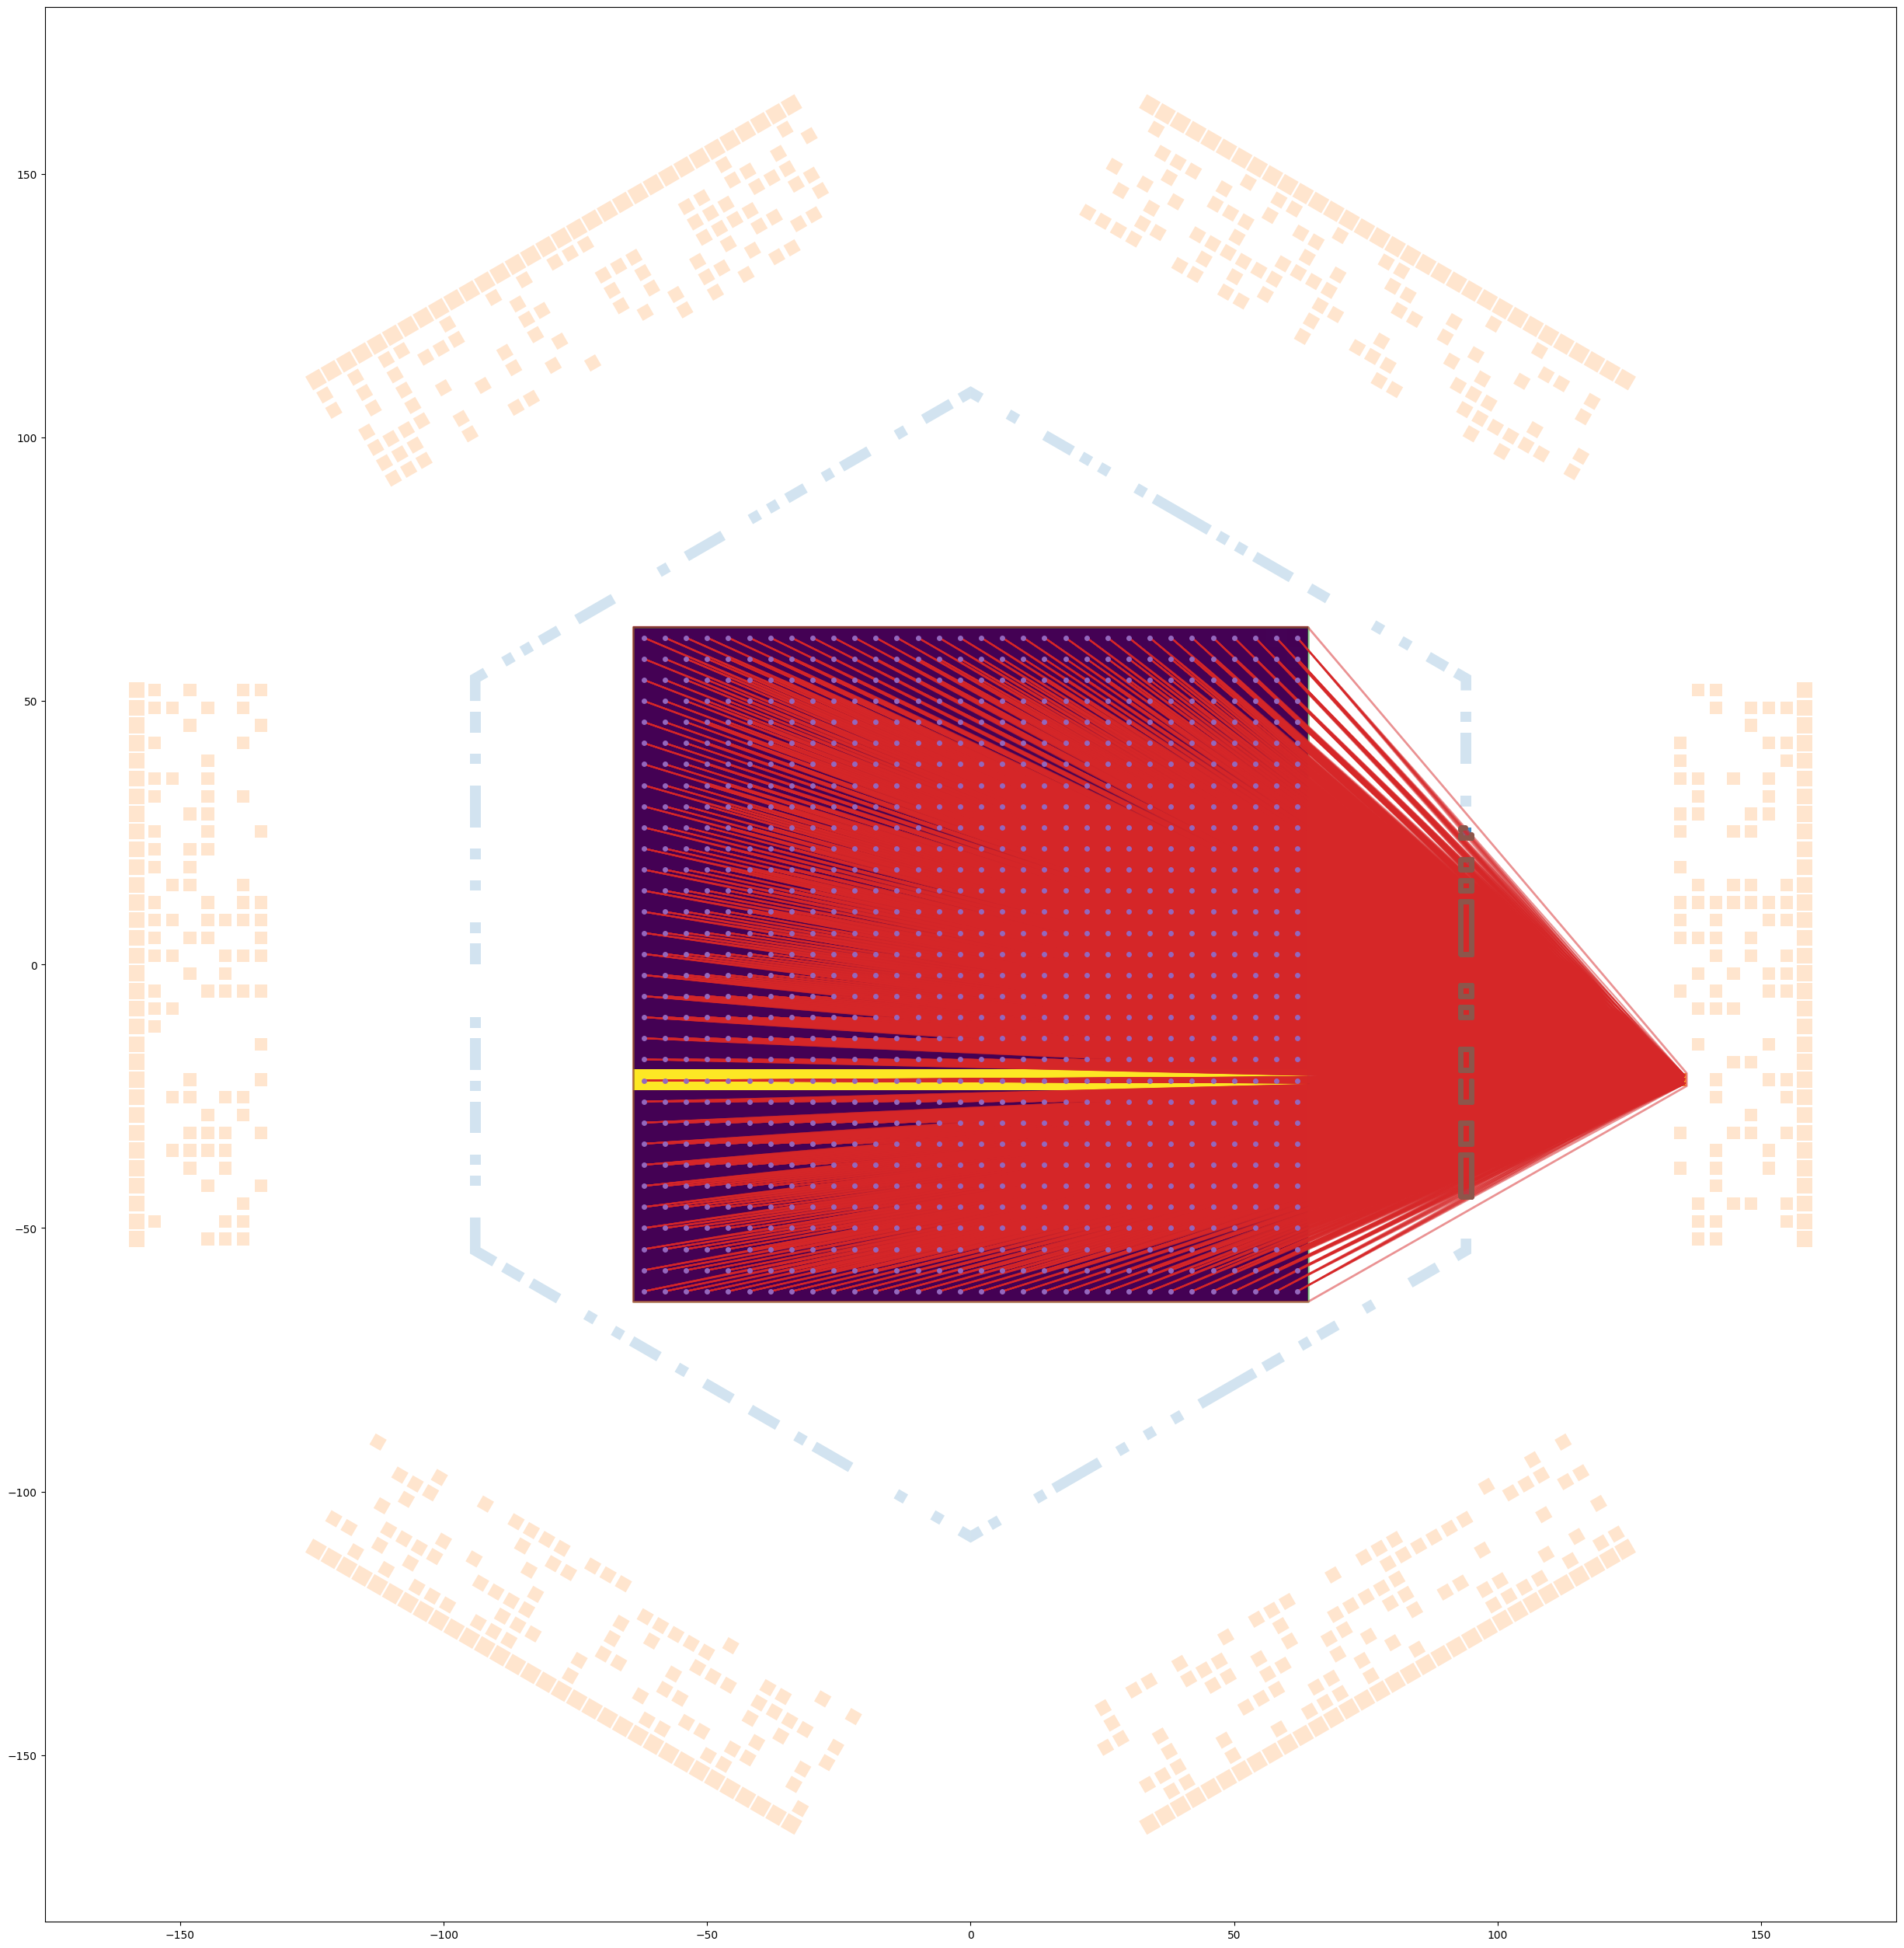

In [5]:
plt.close("all")
fig, ax = plt.subplots(figsize=(32, 32))
plate_objects_polycoll = PolyCollection(
    list(plate_objects_vertices), fc="C0", ec="None", alpha=0.2
)
crystal_objects_polycoll = PolyCollection(
    list(crystal_objects_vertices), fc="C1", ec="None", alpha=0.2
)
fov_corners = fov_corners_vertices_2d(fov_dict)
fov_frame_polycoll = PolyCollection(
    list(fov_corners.unsqueeze(0)), fc="None", ec="C2", alpha=0.5, lw=2
)

reduced_crystal_objects_polycoll = PolyCollection(
    list(crystal_objects_vertices[reduced_crystal_objects_ids]),
    fc="C1",
    ec="None",
    alpha=0.8,
)


local_hull_polycoll = PolyCollection(
    list(local_hull.unsqueeze(0)), fc="None", ec="C3", alpha=0.5, lw=2
)
reduced_plate_objects_polycoll = PolyCollection(
    list(plate_objects_vertices[reduced_plate_objects_ids]),
    fc="C0",
    ec="None",
    alpha=0.8,
)
ax.add_collection(reduced_crystal_objects_polycoll)
ax.add_collection(fov_frame_polycoll)
ax.add_collection(crystal_objects_polycoll)
ax.add_collection(plate_objects_polycoll)
ax.add_collection(reduced_plate_objects_polycoll)
ax.add_collection(local_hull_polycoll)
fov_mpl_extent = tuple(
    (
        fov_dict["size in mm"] * 0.5 * tensor([[-1, 1], [-1, 1]])
        + fov_dict["center coordinates in mm"]
    ).view(-1)
)
print(fov_mpl_extent)


rays_linecoll = LineCollection(
    list(rays.view(-1, 2, 2).numpy()),
    colors="C3",
    
    alpha=0.5,
)
ax.add_collection(rays_linecoll)
ax.plot(
    pa_batch[:, 0].numpy(),
    pa_batch[:, 1].numpy(),
    "o",
    markersize=4,
    color="C4",
)


ax.plot(
    intersection_points_plates[:, :, 0].numpy(),
    intersection_points_plates[:, :, 1].numpy(),
    "o",
    markersize=4,
    color="C5",
)


ax.imshow(
    ppdf.view(int(fov_dict["n pixels"][0]), int(fov_dict["n pixels"][0])).T,
    extent=fov_mpl_extent,
    origin="lower",
    # cmap="",
)
ax.autoscale()

In [6]:
print(intersection_length_plates.shape)
print(intersection_length_crystals.shape)
print(intersection_length_subdivisions.shape)
print(rays_plates_transmission_t.shape)
print(rays_crystal_transmission_t.shape)
print(rays_sub_crystal_t.shape)
print(reduced_plate_objects_ids)

torch.Size([9216, 10])
torch.Size([9216, 1])
torch.Size([1024, 9])
torch.Size([9216, 40])
torch.Size([9216, 4])
torch.Size([1024, 9, 4])
tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])


In [7]:
print(ppdf.mean())

tensor(0.0122, dtype=torch.float64)


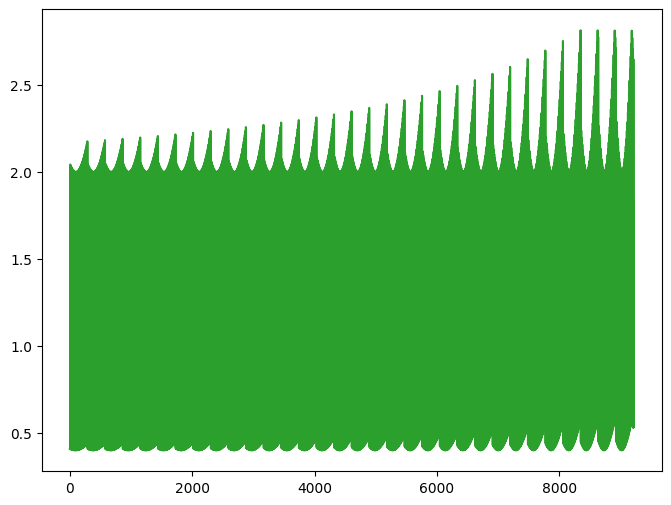

In [8]:
plt.close("all")
fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(ppdf.view(-1).numpy(), "-", markersize=4, color="C0")
# ax.plot(intersection_length_plates.sum(dim=1).numpy(), "-", markersize=4, color="C1")
ax.plot(intersection_length_crystals.sum(dim=1).numpy(), "-", markersize=4, color="C2")

In [ ]:
intersection_length_plates.shape


torch.Size([9216, 10])

In [10]:
intersection_length_plates.sum(dim=1).count_nonzero()


tensor(5249)

In [11]:
32*32*9

9216

In [13]:
rays.shape

torch.Size([1024, 9, 2, 2])

In [83]:
from torch import atan2, float64 as torch_float64


def polygon_to_points_angular_span_2d_batch(
    polygon_vertices_batch: Tensor,
    ref_points_batch: Tensor,
) -> Tensor:
    """
    Calculate the angular span of points within a polygon in 2D.
    """
    polygon_vertices_rads = points_to_refs_angle_2d_batch(
        polygon_vertices_batch.view(-1, 2), ref_points_batch
    ).view(
        ref_points_batch.shape[0],
        polygon_vertices_batch.shape[0],
        polygon_vertices_batch.shape[1],
    )

    polygon_rads_span_batch = (
        polygon_vertices_rads.max(dim=2).values
        - polygon_vertices_rads.min(dim=2).values
    )
    return where(
        polygon_rads_span_batch > pi,
        2 * pi - polygon_rads_span_batch,
        polygon_rads_span_batch,
    )


def points_to_refs_angle_2d_batch(
    points_batch: Tensor, ref_point_batch: Tensor
) -> Tensor:
    """
    Calculate the angle of the points in 2D.
    """
    n_points = points_batch.shape[0]
    n_refs = ref_point_batch.shape[0]
    points_batch = (
        points_batch.to(torch_float64)
        .view(1, n_points, 2)
        .expand(n_refs, -1, -1)
    )
    ref_point = ref_point_batch.view(n_refs, 1, 2).expand(-1, n_points, -1)
    angles = atan2(
        points_batch[:, :, 1] - ref_point[:, :, 1],
        points_batch[:, :, 0] - ref_point[:, :, 0],
    )
    return angles


fov_dict = fov_tensor_dict((64, 64), (128, 128), (0, 0), (1, 1))
crystal_n_subs = (3, 3)
crystal_idx = 380
fov_idx = 0

mu_dict = {"plate": 3.5, "crystal": 0.475}

sfov_pxs_ids, sfov_pxs_coords_batch, sfov_corners_batch = sfov_properties(
    fov_dict
)

sub_crystals_vertices = subdivision_vertices_rectangle(
    crystal_objects_vertices[crystal_idx], subdivision_grid
)

local_hull = convex_hull_2d(
    sort_points_for_hull_2d(
        cat(
            (
                sfov_corners_batch[fov_idx],
                crystal_objects_vertices[crystal_idx],
            ),
            dim=0,
        )
    )
)
reduced_plate_objects_ids, reduced_crystal_objects_ids = (
    reduced_scanner_objects_ids_local(
        crystal_idx,
        local_hull,
        plate_objects_vertices,
        crystal_objects_vertices,
        plate_objects_edges,
        crystal_objects_edges,
    )
)

reduced_plate_edges = plate_objects_edges[reduced_plate_objects_ids]
reduced_crystal_edges = crystal_objects_edges[reduced_crystal_objects_ids]
print(
    f"reduced_plate_objects_ids: {reduced_plate_objects_ids.shape}\n"
    f"reduced_crystal_objects_ids: {reduced_crystal_objects_ids.shape}"
)
print(
    f"reduced_plate_edges: {reduced_plate_edges.shape}",
    f"\nreduced_crystal_edges: {reduced_crystal_edges.shape}",
)
sub_crystals_edges = polygon_edges_from_vertices_2d_batch(sub_crystals_vertices)

pa_batch = sfov_pxs_coords_batch[fov_idx]
pb_batch = sub_crystals_vertices.mean(dim=1)

rays = rays_2d_batch(pa_batch, pb_batch)
rays_plates_transmission_t = line_segments_t(
    rays.view(-1, 2, 2), reduced_plate_edges.view(-1, 2, 2)
)
rays_crystal_transmission_t = line_segments_t(
    rays.view(-1, 2, 2), reduced_crystal_edges.view(-1, 2, 2)
)
rays_sub_crystal_t = rays_edges_t_subdivisions(rays, sub_crystals_edges)

print(
    f"rays_plates_transmission_t: {rays_plates_transmission_t.shape}"
    f"\nrays_crystal_transmission_t: {rays_crystal_transmission_t.shape}"
    f"\nrays_sub_crystal_t: {rays_sub_crystal_t.shape}"
)

intersection_length_plates = rays_intersection_lengths(
    rays, rays_plates_transmission_t
).view(rays.shape[0], rays.shape[1], -1)
intersection_length_crystals = rays_intersection_lengths(
    rays, rays_crystal_transmission_t
).view(rays.shape[0], rays.shape[1], -1)

intersection_length_subdivisions = rays_intersection_lengths(
    rays, rays_sub_crystal_t
).view(rays.shape[0], rays.shape[1])

print(
    f"intersection_length_plates: {intersection_length_plates.shape}\n"
    f"intersection_length_crystals: {intersection_length_crystals.shape}\n"
    f"intersection_length_subdivisions: {intersection_length_subdivisions.shape}"
)


sum_plate_exponent = (intersection_length_plates * float(mu_dict["plate"])).sum(
    dim=2
)
sum_crystal_exponent = (
    intersection_length_crystals * float(mu_dict["crystal"])
).sum(dim=2)
subdivision_exponent = intersection_length_subdivisions * float(
    mu_dict["crystal"]
)
subdivision_rads_span = polygon_to_points_angular_span_2d_batch(
    sub_crystals_vertices, pa_batch
)

ppdf = (
    (-sum_plate_exponent - sum_crystal_exponent).exp()
    * (subdivision_exponent.exp() - 1)
    * subdivision_rads_span
    / (2.0 * pi)
).sum(dim=1)
plate_blocking_distance = intersection_length_plates.sum(dim=(1, 2))
print(
    f"ppdf: {ppdf.shape}\n"
    f"plate_blocking_distance: {plate_blocking_distance.shape}"
)

reduced_plate_objects_ids: torch.Size([11])
reduced_crystal_objects_ids: torch.Size([6])
reduced_plate_edges: torch.Size([11, 4, 2, 2]) 
reduced_crystal_edges: torch.Size([6, 4, 2, 2])
rays_plates_transmission_t: torch.Size([36864, 44])
rays_crystal_transmission_t: torch.Size([36864, 24])
rays_sub_crystal_t: torch.Size([4096, 9, 4])
intersection_length_plates: torch.Size([4096, 9, 11])
intersection_length_crystals: torch.Size([4096, 9, 6])
intersection_length_subdivisions: torch.Size([4096, 9])
ppdf: torch.Size([4096])
plate_blocking_distance: torch.Size([4096])


(tensor(-64.), tensor(64.), tensor(-64.), tensor(64.))


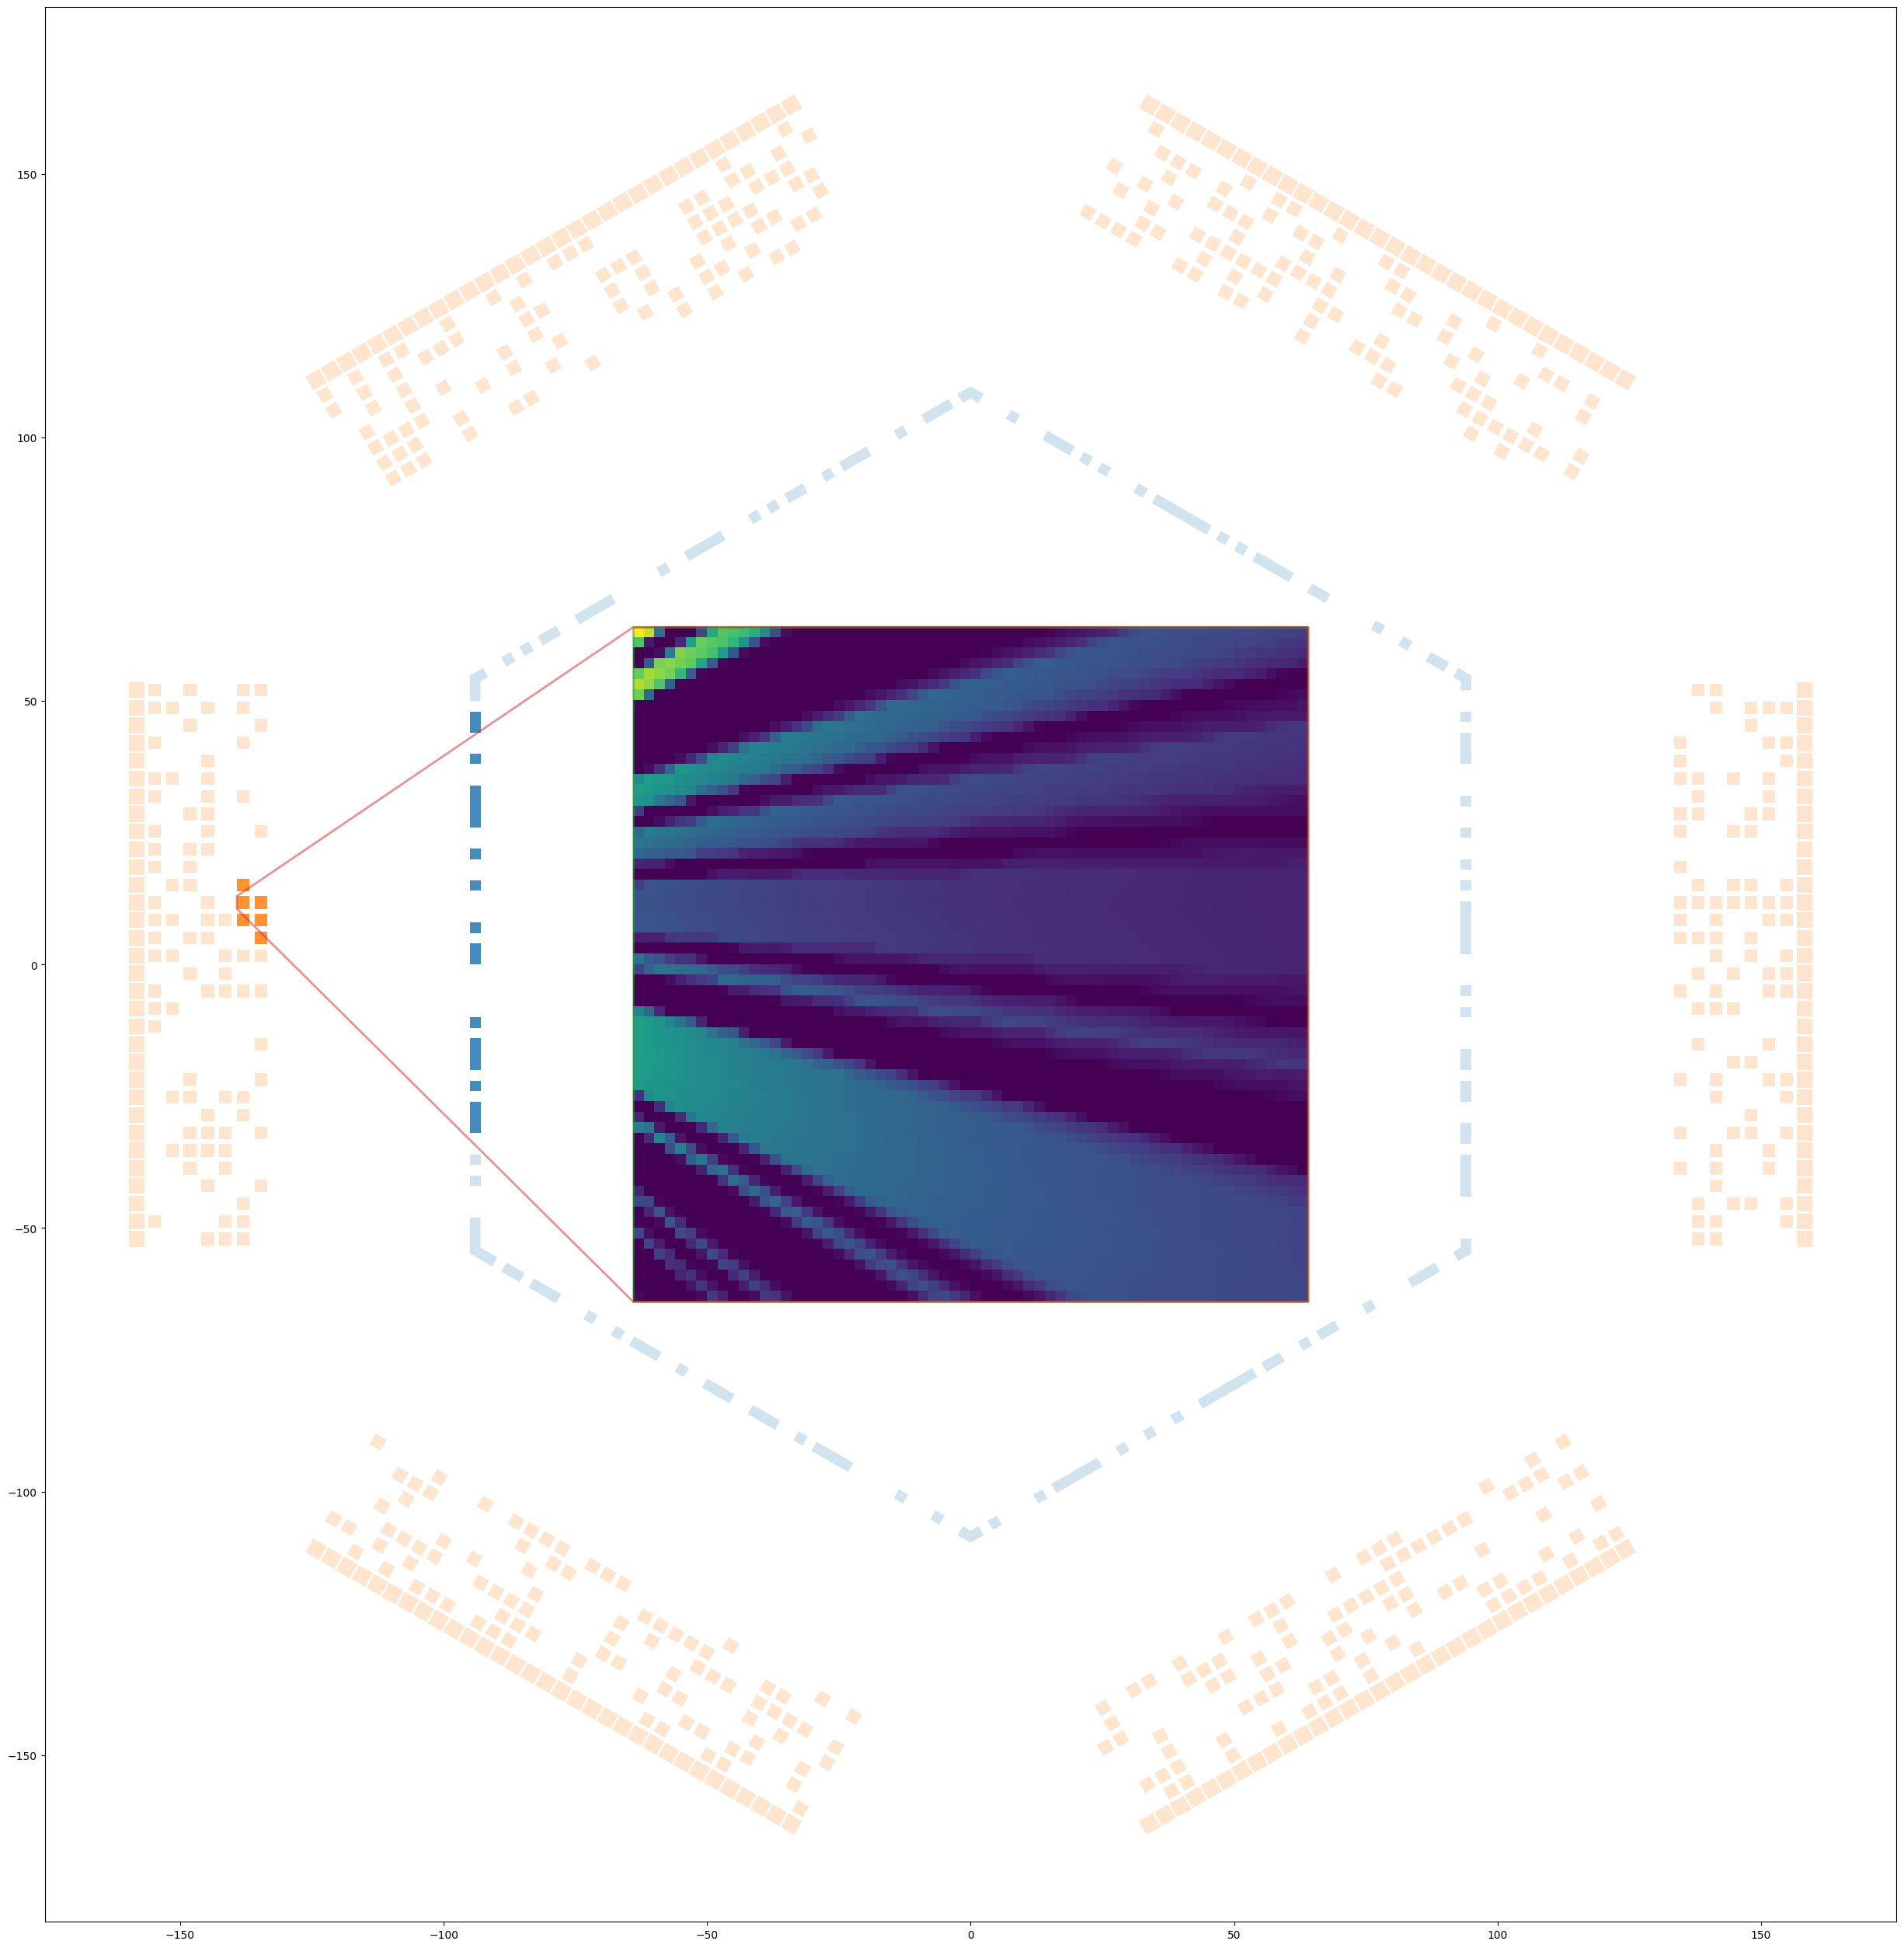

In [84]:
plt.close("all")
fig, ax = plt.subplots(figsize=(32, 32))
plate_objects_polycoll = PolyCollection(
    list(plate_objects_vertices), fc="C0", ec="None", alpha=0.2
)
crystal_objects_polycoll = PolyCollection(
    list(crystal_objects_vertices), fc="C1", ec="None", alpha=0.2
)
fov_corners = fov_corners_vertices_2d(fov_dict)
fov_frame_polycoll = PolyCollection(
    list(fov_corners.unsqueeze(0)), fc="None", ec="C2", alpha=0.5, lw=2
)

reduced_crystal_objects_polycoll = PolyCollection(
    list(crystal_objects_vertices[reduced_crystal_objects_ids]),
    fc="C1",
    ec="None",
    alpha=0.8,
)


local_hull_polycoll = PolyCollection(
    list(local_hull.unsqueeze(0)), fc="None", ec="C3", alpha=0.5, lw=2
)
reduced_plate_objects_polycoll = PolyCollection(
    list(plate_objects_vertices[reduced_plate_objects_ids]),
    fc="C0",
    ec="None",
    alpha=0.8,
)
ax.add_collection(reduced_crystal_objects_polycoll)
ax.add_collection(fov_frame_polycoll)
ax.add_collection(crystal_objects_polycoll)
ax.add_collection(plate_objects_polycoll)
ax.add_collection(reduced_plate_objects_polycoll)
ax.add_collection(local_hull_polycoll)
fov_mpl_extent = tuple(
    (
        fov_dict["size in mm"] * 0.5 * tensor([[-1, 1], [-1, 1]])
        + fov_dict["center coordinates in mm"]
    ).view(-1)
)
print(fov_mpl_extent)


# rays_line_collection = LineCollection(
#     list(rays.view(-1, 2, 2).numpy()),
#     colors="C3",
    
#     alpha=0.5,
# )
# ax.add_collection(rays_line_collection)
# ax.plot(
#     pa_batch[:, 0].numpy(),
#     pa_batch[:, 1].numpy(),
#     "o",
#     markersize=4,
#     color="C4",
# )


# ax.plot(
#     intersection_points_plates[:, :, 0].numpy(),
#     intersection_points_plates[:, :, 1].numpy(),
#     "o",
#     markersize=4,
#     color="C5",
# )


ax.imshow(
    ppdf.view(int(fov_dict["n pixels"][0]), int(fov_dict["n pixels"][0])).T,
    extent=fov_mpl_extent,
    origin="lower",
    # cmap="",
)


ax.autoscale()

(tensor(-64.), tensor(64.), tensor(-64.), tensor(64.))


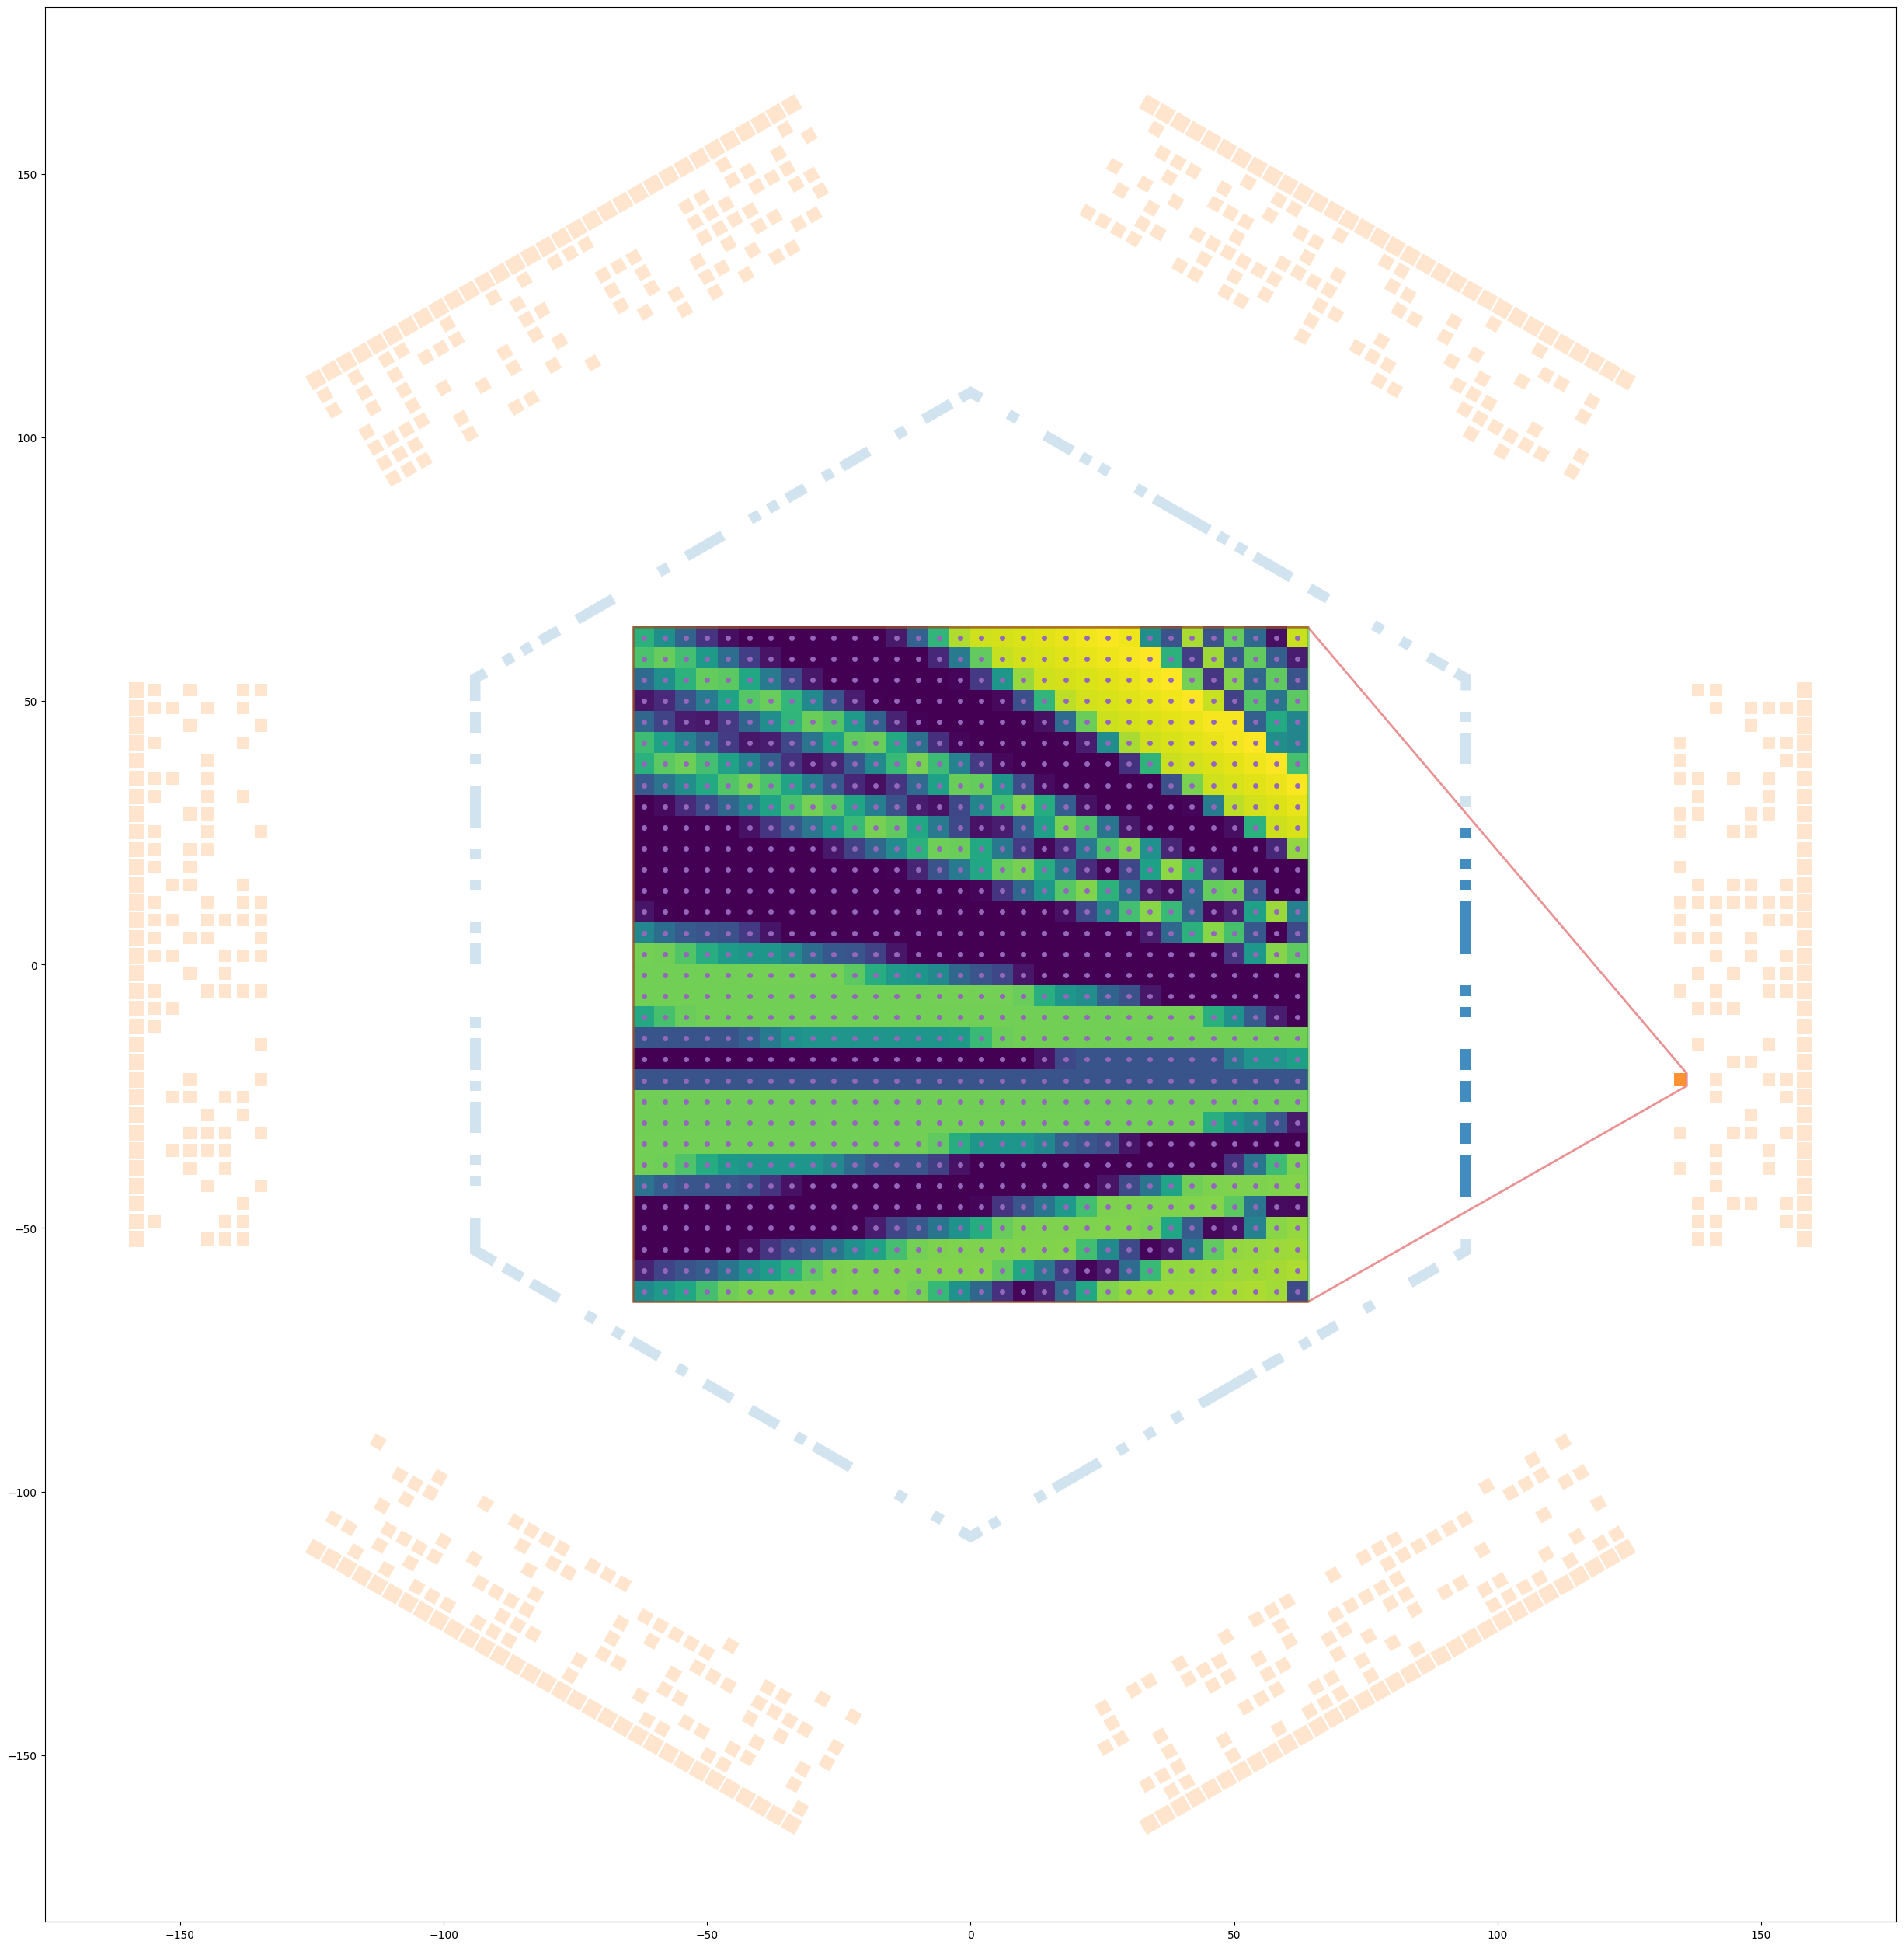

In [71]:
plt.close("all")
fig, ax = plt.subplots(figsize=(32, 32))
plate_objects_polycoll = PolyCollection(
    list(plate_objects_vertices), fc="C0", ec="None", alpha=0.2
)
crystal_objects_polycoll = PolyCollection(
    list(crystal_objects_vertices), fc="C1", ec="None", alpha=0.2
)
fov_corners = fov_corners_vertices_2d(fov_dict)
fov_frame_polycoll = PolyCollection(
    list(fov_corners.unsqueeze(0)), fc="None", ec="C2", alpha=0.5, lw=2
)

reduced_crystal_objects_polycoll = PolyCollection(
    list(crystal_objects_vertices[reduced_crystal_objects_ids]),
    fc="C1",
    ec="None",
    alpha=0.8,
)


local_hull_polycoll = PolyCollection(
    list(local_hull.unsqueeze(0)), fc="None", ec="C3", alpha=0.5, lw=2
)
reduced_plate_objects_polycoll = PolyCollection(
    list(plate_objects_vertices[reduced_plate_objects_ids]),
    fc="C0",
    ec="None",
    alpha=0.8,
)
ax.add_collection(reduced_crystal_objects_polycoll)
ax.add_collection(fov_frame_polycoll)
ax.add_collection(crystal_objects_polycoll)
ax.add_collection(plate_objects_polycoll)
ax.add_collection(reduced_plate_objects_polycoll)
ax.add_collection(local_hull_polycoll)
fov_mpl_extent = tuple(
    (
        fov_dict["size in mm"] * 0.5 * tensor([[-1, 1], [-1, 1]])
        + fov_dict["center coordinates in mm"]
    ).view(-1)
)
print(fov_mpl_extent)


# rays_line_collection = LineCollection(
#     list(rays.view(-1, 2, 2).numpy()),
#     colors="C3",
    
#     alpha=0.5,
# )
# ax.add_collection(rays_line_collection)
ax.plot(
    pa_batch[:, 0].numpy(),
    pa_batch[:, 1].numpy(),
    "o",
    markersize=4,
    color="C4",
)

ax.imshow(
    plate_blocking_distance.view(int(fov_dict["n pixels"][0]), int(fov_dict["n pixels"][0])).T,
    extent=fov_mpl_extent,
    origin="lower",
    # cmap="",
)
ax.autoscale()
# ax.plot(
#     intersection_points_plates[:, :, 0].numpy(),
#     intersection_points_plates[:, :, 1].numpy(),
#     "o",
#     markersize=4,
#     color="C5",
# )

In [47]:
plate_attenuation_term = (-sum_plate_exponent).exp().sum(dim=1)
crystal_attenuation_term = (-sum_crystal_exponent).exp().sum(dim=1)
total_attenuation_term = (
    (-sum_plate_exponent - sum_crystal_exponent).exp().sum(dim=1)
)

total_absorption_term = (subdivision_exponent.exp() - 1).sum(dim=1)
print(
    f"plate_attenuation_term: {plate_attenuation_term.shape}"
    f"\ncrystal_attenuation_term: {crystal_attenuation_term.shape}"
    f"\ntotal_attenuation_term: {total_attenuation_term.shape}"
    f"\ntotal_absorption_term: {total_absorption_term.shape}"
)
ppdf_no_geometry = ((-sum_plate_exponent - sum_crystal_exponent).exp() * (
    subdivision_exponent.exp() - 1.0
)).sum(dim=1)
print(
    f"plate_attenuation_term: {plate_attenuation_term.shape}"
    f"\ncrystal_attenuation_term: {crystal_attenuation_term.shape}"
    f"\ntotal_attenuation_term: {total_attenuation_term.shape}"
    f"\ntotal_absorption_term: {total_absorption_term.shape}"
    f"\nppdf_no_geometry: {ppdf_no_geometry.shape}"
)

plate_attenuation_term: torch.Size([1024])
crystal_attenuation_term: torch.Size([1024])
total_attenuation_term: torch.Size([1024])
total_absorption_term: torch.Size([1024])
plate_attenuation_term: torch.Size([1024])
crystal_attenuation_term: torch.Size([1024])
total_attenuation_term: torch.Size([1024])
total_absorption_term: torch.Size([1024])
ppdf_no_geometry: torch.Size([1024])


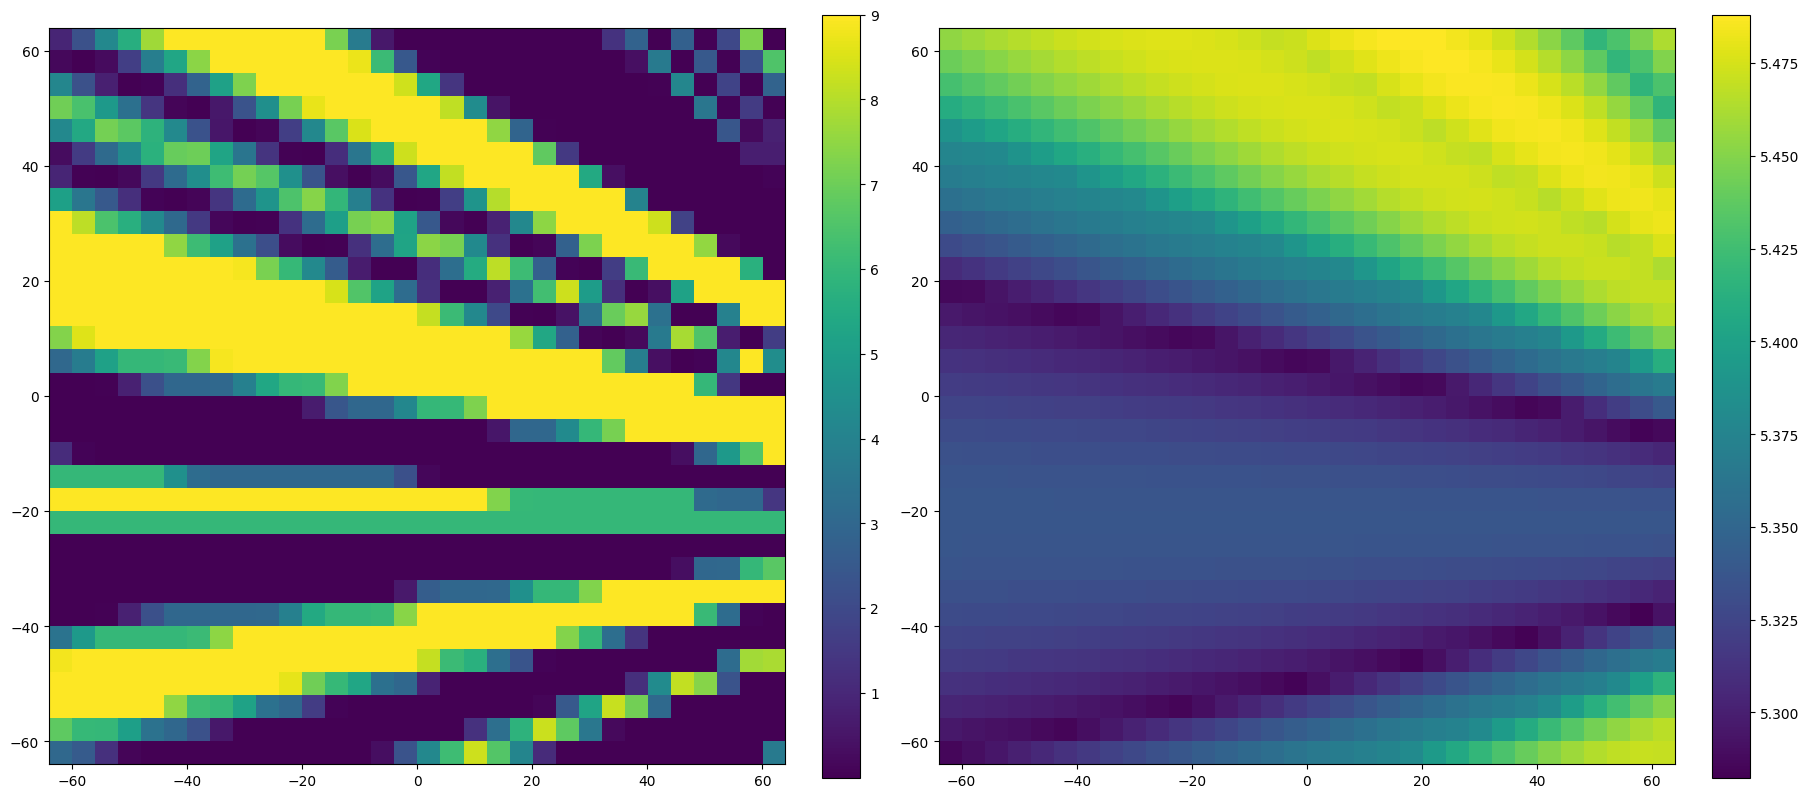

In [42]:
plt.close("all")
fig, axs = plt.subplots(1,2,figsize=(18, 8),layout="constrained")
fov_shape = (int(fov_dict["n pixels"][0]), int(fov_dict["n pixels"][0]))

# axs[0].imshow(
#     plate_attenuation_term.view(fov_shape).T,
#     extent=fov_mpl_extent,
#     origin="lower",
#     # cmap="",
# )
# axs[1].imshow(
#     crystal_attenuation_term.view(fov_shape).T,
#     extent=fov_mpl_extent,
#     origin="lower",
#     # cmap="",
# )
fig.colorbar(axs[0].imshow(
    plate_attenuation_term.view(fov_shape).T,
    extent=fov_mpl_extent,
    origin="lower",
    # cmap="",
), ax=axs[0])
fig.colorbar(axs[1].imshow(
    crystal_attenuation_term.view(fov_shape).T,
    extent=fov_mpl_extent,
    origin="lower",
    # cmap="",
), ax=axs[1])

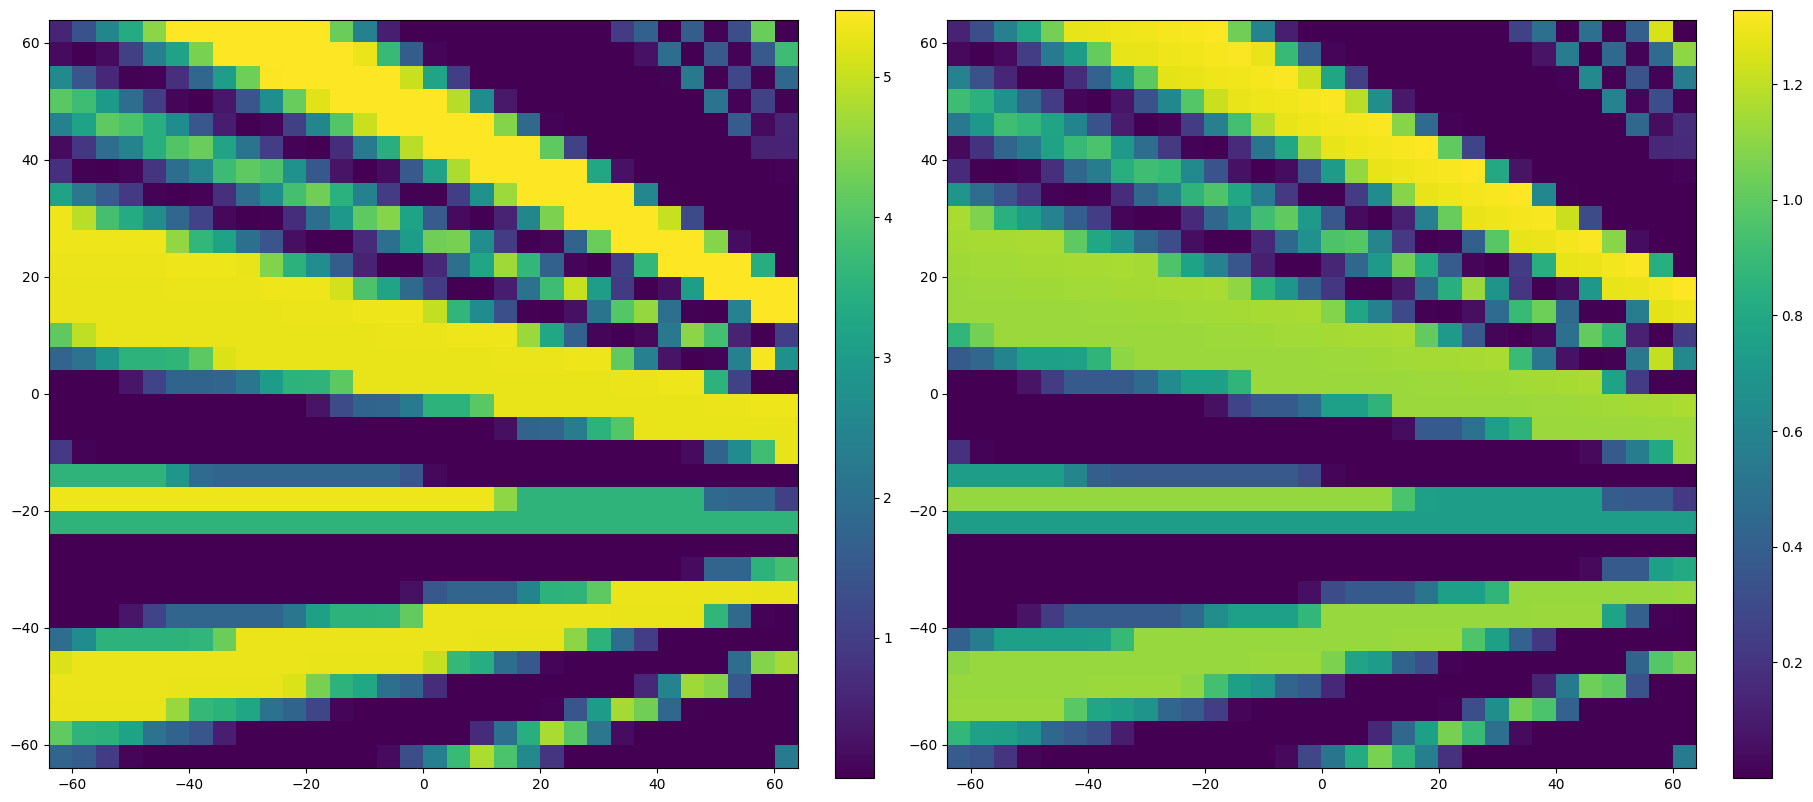

In [48]:
plt.close("all")
fig, axs = plt.subplots(1, 2, figsize=(18, 8), layout="constrained")
fov_shape = (int(fov_dict["n pixels"][0]), int(fov_dict["n pixels"][0]))


fig.colorbar(
    axs[0].imshow(
        total_attenuation_term.view(fov_shape).T,
        extent=fov_mpl_extent,
        origin="lower",
        # cmap="",
    ),
    ax=axs[0],
)
fig.colorbar(
    axs[1].imshow(
        ppdf_no_geometry.view(fov_shape).T,
        extent=fov_mpl_extent,
        origin="lower",
        # cmap="",
    ),
    ax=axs[1],
)

In [ ]:



sub_crystals_vertices_rads = points_to_refs_angle_2d_batch(
    sub_crystals_vertices.view(-1, 2), pa_batch
).view(
    pa_batch.shape[0],
    sub_crystals_vertices.shape[0],
    sub_crystals_vertices.shape[1],
)

subdivision_rads_span = (
    sub_crystals_vertices_rads.max(dim=2).values
    - sub_crystals_vertices_rads.min(dim=2).values
)
print(subdivision_rads_span[subdivision_rads_span > pi].shape)
angular_term = subdivision_rads_span / (2.0 * pi)

print(f"sub_crystals_vertices_rads: {sub_crystals_vertices_rads.shape}")
sub_crystals_vertices_degrees_mean = (
    sub_crystals_vertices_rads.mean(dim=(1, 2)) / pi * 180.0
)

torch.Size([0])
sub_crystals_vertices_rads: torch.Size([1024, 9, 4])
